## SB Scheme on MNIST Data

**Author**: Medha Agarwal

**Date Modified**: Novemnber 4, 2024

IN this notebook, we consider particles distributed as MNIST data. 

In [122]:
import numpy as np
import os
import sys
from tqdm import tqdm
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from estimate_SB import sinkhorn


In [110]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams["axes.labelsize"] = 20
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

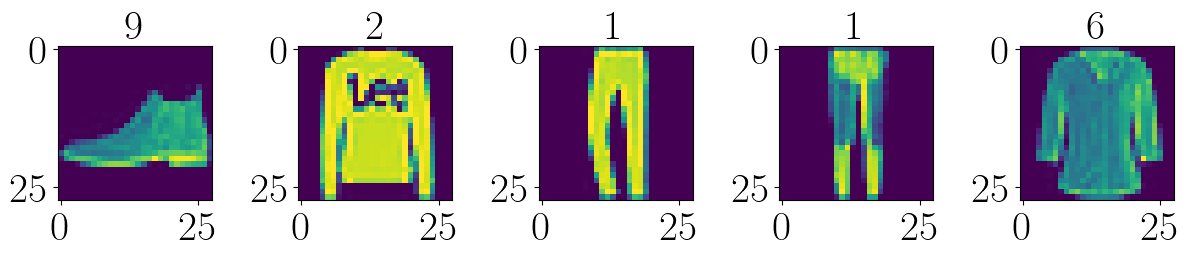

In [108]:
# Define transformations for the dataset (e.g., normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.view(-1))
])

# Load both train and test portions of MNIST
train_dataset = datasets.FashionMNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='data', train=False, transform=transform, download=True)

# Concatenate the train and test datasets into one dataset
full_dataset = ConcatDataset([train_dataset, test_dataset])

dataloader = DataLoader(full_dataset, shuffle=True, batch_size=1000)
# Example: Iterate over the full loader

fig, axs = plt.subplots(1, 5, figsize = (15,2))
for i in range(5):
    image = test_dataset[i][0].view(28, 28)
    axs[i].imshow(image)
    axs[i].set_title(test_dataset[i][1])




In [94]:

def cost_matrix(X, Y):
    """L2 cost matrix
    """
    n, d = X.shape[0], X.shape[1]
    X, Y = torch.tensor(X), torch.tensor(Y)
    return ((torch.cdist(X, Y, p=2))**2).numpy()

def sinkhorn(cost_mat, a, b, epsilon, precision=1e-8, maxiter=1000):
    """Computes EOT statistic with Sinkhorn algorithm.

    Parameters
    ----------
    cost_mat : array-like, shape (size, size)
        Cost matrix between two samples.
    a : array-like, shape (size,)
        Discrete probability distribution along first marginal.  
    b : array-like, shape (size,)
        Discrete probability distribution along second marginal.  
    epsilon : float
        Regularization parameter.
    precision : float
        Precision for when to stop the Sinkhorn update.

    Returns
    -------
    cost : float
        Computed EOT cost
    P : array-like, shape (size, size)
        Minimizer of EOT
    all_costs: list
        evolution of Schrodingerb cost with Sinkhorn iterations
    """
    a = a.reshape((cost_mat.shape[0], ))
    b = b.reshape((cost_mat.shape[1], ))
    K = np.exp(-cost_mat/epsilon)
    
    # initialization
    u = np.ones((cost_mat.shape[0], ))
    v = np.ones((cost_mat.shape[1], ))
    P = np.diag(u.flatten()) @ K @ np.diag(v.flatten())
    p_norm = np.trace(P.T @ P)
    all_costs = []

    for _ in range(maxiter):
        u = a/np.maximum((K @ v), 1e-300) # avoid divided by zero
        v = b/np.maximum((K.T @ u), 1e-300)
        P = np.diag(u.flatten()) @ K @ np.diag(v.flatten())
        if abs((np.trace(P.T @ P) - p_norm)/p_norm) < precision:
            break
        p_norm = np.trace(P.T @ P)
        cost = np.trace(cost_mat.T @ P)
        all_costs.append(cost)
    return cost, P, all_costs
    
def entropy_SB_scheme_sinkhorn(X, steps=[1], eps=0.01, precision=1e-8, maxiter=1e6, forward=True, dir=None):

    """
    Implements the Sinkhorn-based approximation of explicit Euler discretization (forward & reverse) of the gradient flow of entropy function.

    Arguments
    -----------------------
    X: np array-like 
        All particles sampled from the starting distribution.

    steps: list, optional, default=[1]
        List of time steps at which to record the state of the array X.

    eps: float, optional, default=0.01
        Epsilon value for the Sinkhorn algorithm.

    precision: float, optional, default=1e-8
        Precision for the Sinkhorn algorithm convergence.

    maxiter: int, optional, default=1e6
        Maximum number of iterations for the Sinkhorn algorithm.

    forward: bool, optional, default=True
        Direction of the Euler discretization. If True, perform forward discretization, otherwise reverse.

    dir: str or None, optional, default=None
        Directory path to save the state of X at specified steps. If None, states are not saved.

    Returns
    -----------------------
    np.array
        Array containing the state of X at the specified steps.
    """

    start = X
    n, d = X.shape[0], X.shape[1]
    total_steps = steps[-1]
    X_list = [X]
    if dir:
        np.save(os.path.join(dir, f'eps{eps}_time{int(total_steps*eps)}.npy'), np.array(X_list))

    for i in tqdm(range(total_steps)):
   
        cost_mat = cost_matrix(X, X)

        _, avg_plan, _ = sinkhorn(cost_mat, np.ones(n)/n, np.ones(n)/n, epsilon=eps, precision=precision, maxiter=maxiter)
        bar_proj = n*np.matmul(avg_plan, X.reshape(n,d)).reshape(n,d)
        if forward:
            X = 2*X - bar_proj
        else:
            X = bar_proj

        if i+1 in steps:
            X_list.append(X)
            print(f'Epsilon: {eps}, Steps: {i+1}, Distance from start: {np.linalg.norm(start-X)}')
            if dir:
                np.save(os.path.join(dir, f'eps{eps}_time{int(total_steps*eps)}.npy'), np.array(X_list))

    return np.array(X_list)


In [151]:
X, _ = next(iter(dataloader))

# Perform PCA to reduce to a specified number of components
n_components = 100  # Example: reduce to 50 components
pca = PCA(n_components=n_components)

mnist_samples_pca = pca.fit_transform(X)
inverse_X = pca.inverse_transform(mnist_samples_pca)

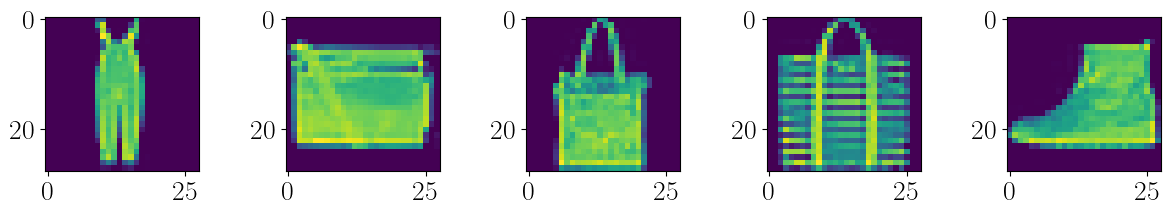

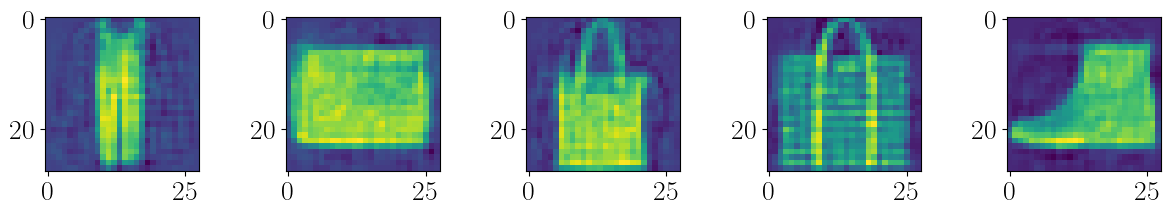

In [152]:
fig, axs = plt.subplots(1, 5, figsize=(15, 2))
for i in range(5):
    axs[i].imshow(X[i].reshape(28, 28))
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(15, 2))
for i in range(5):
    axs[i].imshow(inverse_X[i].reshape(28, 28))
plt.show()


In [161]:
cost_mat = cost_matrix(mnist_samples_pca, mnist_samples_pca)
n = mnist_samples_pca.shape[0]

(11, 500, 784)


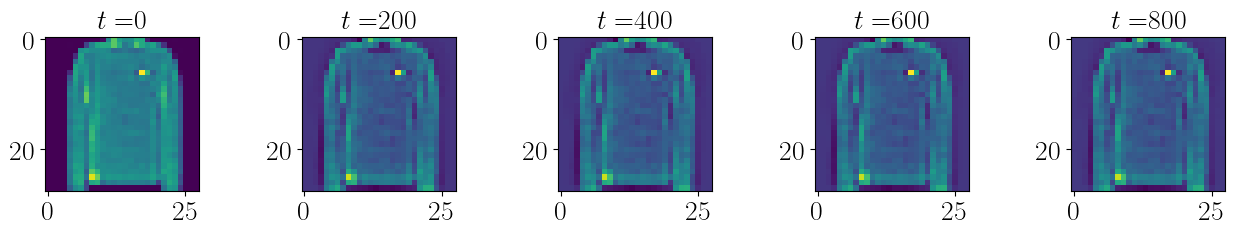

In [167]:
dir = f'results/FashionMNIST'
os.makedirs(dir, exist_ok=True)

X_list = np.load(os.path.join(dir, f'eps{50}.npy'))
print(X_list.shape)

fig, axs = plt.subplots(1, len(X_list)//2, figsize=(3*len(X_list)//2, 2))
for i in range(0, len(X_list)//2):
    axs[i].imshow(X_list[i][1].reshape(28, 28))
    time = 100*i*2
    axs[i].set_title(f'$t = ${time}')